In [1]:
%load_ext autoreload
%autoreload 2



## setup the schema

In [150]:
import os
import os
import datajoint as dj
from djimaging.user.ssuhai.schemas.ssuhai_schema import *
from djimaging.utils.dj_utils import activate_schema



In [3]:
username = !whoami
username = username[0]
home_directory = os.path.expanduser("~")
path_to_djimaging = f'{home_directory}/GitRepos'
config_file = f'{home_directory}/datajoint/dj_{username}_conf.json'
assert os.path.isfile(config_file), f'Set the path to your config file: {config_file}'
schema_name = f"ageuler_{username}_test"


In [151]:
# Load configuration for user
dj.config.load(config_file)
dj.config['schema_name'] = schema_name

print("schema_name:", dj.config['schema_name'])
dj.conn()

schema_name: ageuler_ssuhai_test


DataJoint connection (connected) ssuhai@172.25.240.200:3306

In [152]:
activate_schema(schema=schema, create_schema=True, create_tables=True)


[2025-04-11 17:36:24,223][INFO]: could not log event in table ~log


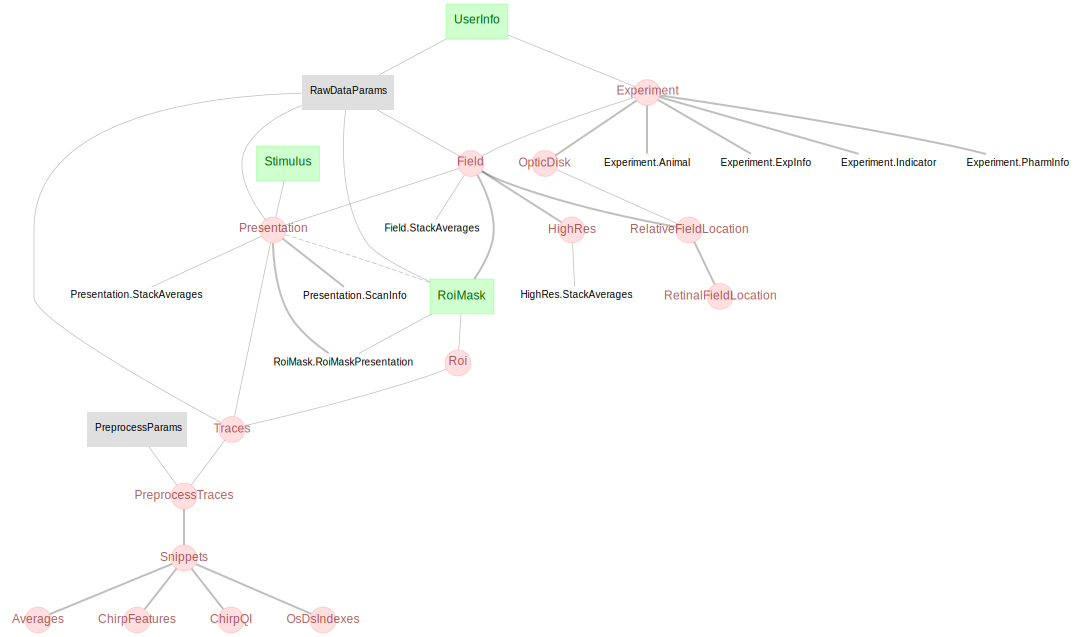

In [153]:
dj.ERD(schema)

## Looping

### set parameters of tables and some user metadata

In [154]:
# 1. Set initial user info

userinfo = {
    'experimenter': 'closedlooptest', # Replace this if you want to use your own data
    'data_dir': '/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/updated_loop_data', # Replace this if you want to use your own data
    'datatype_loc': 0,
    'animal_loc': 1,
    'region_loc': 2,
    'field_loc': 3,
    'stimulus_loc': 4,
    'condition_loc': 5,
}
UserInfo().upload_user(userinfo)


In [155]:
# 2. set parameters for Raw data
RawDataParams().add_default()


### set initial data in Experiment table

In [156]:
# verboselvl 1 is only new files
Experiment().rescan_filesystem(verboselvl=1)
Field().rescan_filesystem(verboselvl=1)


Scanning for experimenter: closedlooptest
	header_path: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/updated_loop_data/20250411/2
		header_name: 20190701__left.ini
		Adding: {'experimenter': 'closedlooptest', 'date': datetime.datetime(2025, 4, 11, 0, 0), 'exp_num': 2}
	header_path: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/updated_loop_data/20250411/1
		header_name: 20190701__left.ini
		Adding: {'experimenter': 'closedlooptest', 'date': datetime.datetime(2025, 4, 11, 0, 0), 'exp_num': 1}
Processing fields in: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/updated_loop_data/20250411/1/Pre
	Adding field: `GCL0` with files: ['SMP_M1_LR_GCL0_Chirp.h5']
Processing fields in: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/updated_loop_data/20250411/2/Pre
	Adding field: `GCL0` with files: ['SMP_M1_LR_GCL0_Chirp.h5']


In [157]:
# TODO add custom stimulus class for dynamic stimuli
Stimulus().add_chirp(spatialextent=1000, stim_name='gChirp', alias="chirp_gchirp_globalchirp", skip_duplicates=True)

In [158]:
# add to List of presentaitons
Presentation().populate(processes=20, display_progress=True)

Processes:   0%|          | 0/2 [00:00<?, ?it/s]

Processes: 100%|██████████| 2/2 [00:00<00:00,  2.46it/s]


{'success_count': 2, 'error_list': []}

In [159]:
# load ROI masks if they exist
RoiMask().rescan_filesystem(verboselvl=2)
missing_fields = RoiMask().list_missing_field()
field_key = missing_fields[0]
roi_canvas = RoiMask().draw_roi_mask(field_key=field_key, canvas_width=30)
#roi_canvas.start_gui()
roi_canvas.insert_database(roi_mask_tab=RoiMask, field_key=field_key)


No ROI masks found for field: {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 4, 11), 'exp_num': 1, 'raw_id': 1, 'field': 'GCL0'}
No ROI masks found for field: {'experimenter': 'closedlooptest', 'date': datetime.date(2025, 4, 11), 'exp_num': 2, 'raw_id': 1, 'field': 'GCL0'}
Loaded ROI mask from file=/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/updated_loop_data/20250411/1/Pre/SMP_M1_LR_GCL0_Chirp.h5 for files=
['/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/updated_loop_data/20250411/1/Pre/SMP_M1_LR_GCL0_Chirp.h5']
for mask_alias=chirp_mb_movingbar
Load model weights for cpu from checkpoint /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/dropout_and_aug_regul.ckpt using config /gpfs01/euler/data/Resources/AutoROIs/models/UNET_v0.1.0/sd_images.yaml


/gpfs01/euler/User/ssuhai/GitRepos/djimaging/djimaging/tables/misc/highresolution.py:35: UserWarning: Custom package `scanmsupport is not installed. Cannot load SMP files.
  warnings.warn('Custom package `scanmsupport is not installed. Cannot load SMP files.')


Returned InteractiveRoiCanvas object. To start GUI, call <enter_object_name>.start_gui().


In [160]:
Roi().populate(processes=20, display_progress=True)
Traces().populate(processes=20, display_progress=True)


Roi:   0%|          | 0/1 [00:00<?, ?it/s]

Traces: 100%|██████████| 1/1 [00:00<00:00,  1.37it/s]


{'success_count': 1, 'error_list': []}

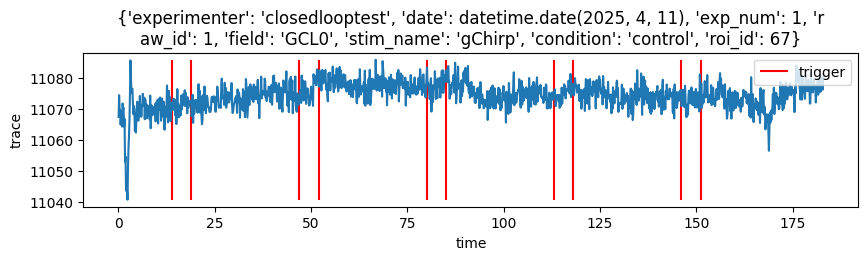

In [161]:
Traces().plot1()

### add another recording

What we minimally want is to reuse the sme ROI masks, since the whole point it that we look at the same cells multiple times. 

Therefore we could 
1. Define new experiment: 
    a. just another number in date folder and Use same Field name.
    b. need to update presentation table as well 
2. Add the stimulus used 
3. Vertically stack the RoiMask and and Roi tables just changing the exp_num table 
4. Populate Traces again 

In [ ]:
# 1. 
Experiment().rescan_filesystem(verboselvl=1)
Field().rescan_filesystem(verboselvl=1)


Scanning for experimenter: closedlooptest
	header_path: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/updated_loop_data/20250411/2
		header_name: 20190701__left.ini
		Adding: {'experimenter': 'closedlooptest', 'date': datetime.datetime(2025, 4, 11, 0, 0), 'exp_num': 2}
	header_path: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/updated_loop_data/20250411/1
		header_name: 20190701__left.ini
Processing fields in: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/updated_loop_data/20250411/1/Pre
Processing fields in: /gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/updated_loop_data/20250411/2/Pre
	Adding field: `GCL0` with files: ['SMP_M1_LR_GCL0_Chirp.h5']


Presentation: 100%|██████████| 1/1 [00:00<00:00,  3.14it/s]


{'success_count': 1, 'error_list': []}

In [139]:
# 2. add another stimulus
Stimulus().add_chirp(spatialextent=300, stim_name='lChirp', alias="lchirp_localchirp", skip_duplicates=True)


In [140]:
initial_roi_mask: dict = RoiMask().fetch(as_dict=True)[0]
initial_roi = Roi().fetch(as_dict=True)

# incrase exp_num by 1
initial_roi_mask['exp_num'] += 1

In [147]:
# insert into roi and roimask table 
RoiMask().insert1(initial_roi_mask)
Presentation().populate(processes=20, display_progress=True)


DuplicateError: ("Duplicate entry 'closedlooptest-2025-04-11-2-1-GCL0' for key 'roi_mask.PRIMARY'", 'To ignore duplicate entries in insert, set skip_duplicates=True')

In [143]:
Roi().populate(processes=20, display_progress=True)
Traces().populate(processes=20, display_progress=True)

Roi:   0%|          | 0/1 [00:00<?, ?it/s]

Roi: 100%|██████████| 1/1 [00:00<00:00,  4.41it/s]


{'success_count': 0, 'error_list': []}

In [145]:
Traces()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,stim_name Unique string identifier,condition condition (pharmacological or other),roi_id integer id of each ROI,trace array of raw trace,trace_times numerical array of trace times,trace_flag Are values in trace correct (1) or not (0)?,trigger_flag Are triggertimes inside trace_times (1) or not (0)?
closedlooptest,2025-04-11,1,1,GCL0,gChirp,control,1,=BLOB=,=BLOB=,1,1
closedlooptest,2025-04-11,1,1,GCL0,gChirp,control,2,=BLOB=,=BLOB=,1,1
closedlooptest,2025-04-11,1,1,GCL0,gChirp,control,3,=BLOB=,=BLOB=,1,1
closedlooptest,2025-04-11,1,1,GCL0,gChirp,control,4,=BLOB=,=BLOB=,1,1
closedlooptest,2025-04-11,1,1,GCL0,gChirp,control,5,=BLOB=,=BLOB=,1,1
closedlooptest,2025-04-11,1,1,GCL0,gChirp,control,6,=BLOB=,=BLOB=,1,1
closedlooptest,2025-04-11,1,1,GCL0,gChirp,control,7,=BLOB=,=BLOB=,1,1
closedlooptest,2025-04-11,1,1,GCL0,gChirp,control,8,=BLOB=,=BLOB=,1,1
closedlooptest,2025-04-11,1,1,GCL0,gChirp,control,9,=BLOB=,=BLOB=,1,1
closedlooptest,2025-04-11,1,1,GCL0,gChirp,control,10,=BLOB=,=BLOB=,1,1


In [123]:
RoiMask.add_field_roi_masks()

TypeError: RoiMaskTemplate.add_field_roi_masks() missing 2 required positional arguments: 'self' and 'field_key'

In [113]:
Traces.roi_mask_table.RoiMaskPresentation()

experimenter name of the experimenter,date date of recording,exp_num experiment number in a day,raw_id unique param set id,field string identifying files corresponding to field,stim_name Unique string identifier,condition condition (pharmacological or other),roi_mask ROI mask for presentation field,as_field_mask relationship to field mask,shift_dx Shift in x,shift_dy Shift in y
closedlooptest,2025-04-11,1,1,GCL0,gChirp,control,=BLOB=,same,0,0


In [87]:
Traces().populate(processes=20, display_progress=True) 

{'success_count': 0, 'error_list': []}

In [68]:
# add to List of presentaitons
Presentation().populate(processes=20, display_progress=True)

Processes: 100%|██████████| 3/3 [00:00<00:00,  8.24it/s]


{'success_count': 3, 'error_list': []}

In [118]:
Traces().populate(processes=20, display_progress=True)

{'success_count': 0, 'error_list': []}

In [102]:
UserInfo()

experimenter name of the experimenter,"data_dir path to header file, used for computed tables",datatype_loc string location for datatype (e.g. SMP),animal_loc string location for number of animal (e.g. M1),region_loc string location for region (e.g. LR or RR),field_loc string location for field,stimulus_loc string location for stimulus,condition_loc string location for (pharmacological) condition,opticdisk_alias alias(es) for optic disk recordings (separated by _),outline_alias alias(es) for retinal outline / edge recordings (separated by _),highres_alias alias(es) for high resolution stack,mask_alias Ordered alias(es) for field roi mask (separated by _),pre_data_dir directory for h5 data files,raw_data_dir directory for smp and smh data files,"data_stack_name main data channel, e.g. OGB-1","alt_stack_name alternative data channel, e.g. SR101"
closedlooptest,/gpfs01/euler/User/ssuhai/GitRepos/simulation_closed_loop/data/recordings/updated_loop_data/,0,1,2,3,4,5,od_opticdisk_opticdisc,outline_edge,hq_hr_highresolution_512,chirp_mb_movingbar,Pre,Raw,wDataCh0,wDataCh1


In [162]:
if input("Continue with cleaning up? (yes/no))") != "yes":
    raise ValueError('Enter yes if you wish to continue.')

schema.drop()